In [12]:
import torch
from torch_geometric.data import Data

edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)
x = torch.tensor([[-1], [0], [1]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index.contiguous())

In [13]:
data.validate(raise_on_error=True)

True

In [20]:
edge_index.size()

torch.Size([2, 4])

In [21]:
print(data.keys())

['x', 'edge_index']


In [22]:
print(data['x'])

tensor([[-1.],
        [ 0.],
        [ 1.]])


In [23]:
for key, item in data:
    print(f'{key} found in data')

x found in data
edge_index found in data


In [24]:
'edge_attr' in data

False

In [25]:
data.num_nodes

3

In [26]:
data.num_edges

4

In [27]:
data.num_node_features

1

In [28]:
data.has_isolated_nodes()

False

In [29]:
data.has_self_loops()

False

In [30]:
data.is_directed()

False

In [31]:
device = torch.device('cuda')
data = data.to(device)

In [32]:
from torch_geometric.datasets import TUDataset

In [96]:
dataset = TUDataset(root='/tmp/ENZYMES', name='ENZYMES')

In [34]:
len(dataset)

600

In [66]:
dataset.num_classes

6

In [65]:
dataset.num_node_features

3

In [68]:
dataset.num_node_features

3

In [39]:
dataset

ENZYMES(600)

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


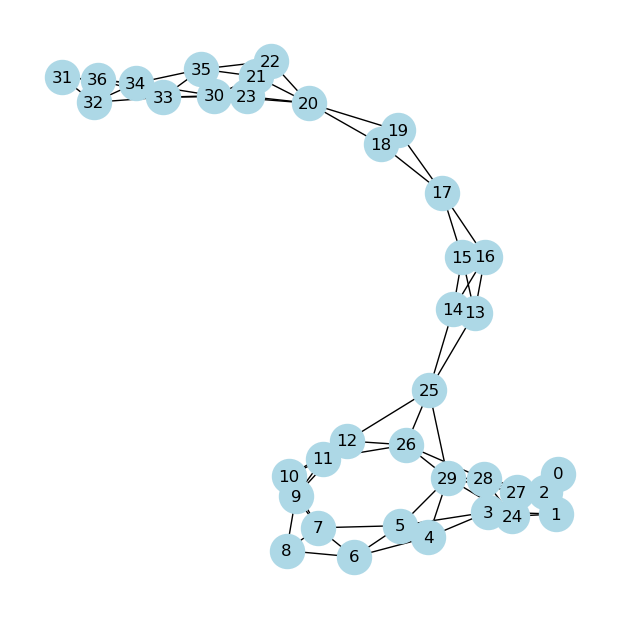

In [69]:

data=dataset[0]
G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(6, 6))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=600)
plt.show()


In [74]:
data=dataset[43]
data

Data(edge_index=[2, 190], x=[45, 3], y=[1])

In [53]:
data.is_undirected()

True

In [54]:
train_dataset = dataset[:540]

In [55]:
test_dataset = dataset[540:]

In [56]:
dataset = dataset.shuffle()


In [57]:
perm = torch.randperm(len(dataset))
dataset = dataset[perm]

In [77]:
# y=[1] (size of target) | dataset.num_classes -> 6 (different possible target values)
data.y.shape

torch.Size([1])

In [78]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='/tmp/Cora', name='Cora')

Processing...
Done!


In [95]:
data = dataset[0]
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [ ]:
# data.is_undirected() # True
# data.train_mask.sum().item() # 140
# data.val_mask.sum().item() # 500
# data.test_mask.sum().item() # 1000
# Each node acts as a record

1000

In [99]:
# After importing Enzyme data from 16th cell
from torch_geometric.loader import DataLoader
loader =DataLoader(dataset,batch_size=32,shuffle=True)

for batch in loader:
    print(batch)

DataBatch(edge_index=[2, 3584], x=[958, 3], y=[32], batch=[958], ptr=[33])
DataBatch(edge_index=[2, 3666], x=[967, 3], y=[32], batch=[967], ptr=[33])
DataBatch(edge_index=[2, 4358], x=[1164, 3], y=[32], batch=[1164], ptr=[33])
DataBatch(edge_index=[2, 3926], x=[1025, 3], y=[32], batch=[1025], ptr=[33])
DataBatch(edge_index=[2, 4290], x=[1126, 3], y=[32], batch=[1126], ptr=[33])
DataBatch(edge_index=[2, 3876], x=[983, 3], y=[32], batch=[983], ptr=[33])
DataBatch(edge_index=[2, 3892], x=[1006, 3], y=[32], batch=[1006], ptr=[33])
DataBatch(edge_index=[2, 3696], x=[947, 3], y=[32], batch=[947], ptr=[33])
DataBatch(edge_index=[2, 3804], x=[1098, 3], y=[32], batch=[1098], ptr=[33])
DataBatch(edge_index=[2, 4414], x=[1139, 3], y=[32], batch=[1139], ptr=[33])
DataBatch(edge_index=[2, 4328], x=[1101, 3], y=[32], batch=[1101], ptr=[33])
DataBatch(edge_index=[2, 4018], x=[1050, 3], y=[32], batch=[1050], ptr=[33])
DataBatch(edge_index=[2, 4208], x=[1128, 3], y=[32], batch=[1128], ptr=[33])
DataBat

In [101]:
for batch in loader:
    print(batch.num_graphs)

32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
24
